# Azimuthal-modulation analysis -- TRM model: `TRM_paper`

Companion, additive analysis alongside the harmonic-fit pipeline (see
`harmonic_pipeline_TRM_paper.ipynb`, which ends at the `V_rad` result
and the PA degeneracy) -- not one of its Section 0 deliverables. All
computation lives in `azimuthal_modulation.py`; this notebook only imports
it and displays figures (`azimuthal_plots.py`), mirroring the split already
used by `harmonic_fit.py` / `harmonic_plots.py`.

Other TRM models with a results/ring_results.ecsv already fit: fixed_PA42.

**Motivation.** The harmonic decomposition returns `V_rad` (`s1`) consistent
with zero in every ring. Two explanations are compatible with that:
**(A)** there is genuinely no coherent radial motion, or **(B)** there is
radial motion whose amplitude and sign vary with azimuth, averaged toward
zero by a fit with only one `sin(theta)` term. Wallin & Struck-Marcell
(1994) predict (B) for an off-centre collision like the one proposed here.

**Three statistics used by an earlier version of this analysis were
invalid** and are fixed in `azimuthal_modulation.py` before anything else is
added:

1. **`delta_chi2` was not a likelihood ratio.** It mixed the fit's own
   objective (`sum(w*resid^2)`, `w=sin^2(theta)`) with a differently-weighted
   chi2 (`sum((resid/sigma)^2)`), so it could -- and did (ring 3:
   `delta_chi2 = -0.04`) -- go negative for a nested model, which is
   impossible. Replaced with a **parametric bootstrap likelihood-ratio
   test** (`parametric_null_bootstrap`): one consistent objective `S`
   throughout, a null distribution built by resampling the best-fit 2-term
   model's own residuals in beam-sized blocks, and `p_bootstrap` calibrated
   empirically rather than assumed to follow chi2(2).
2. **`V_r1` is positive-definite** (a Rayleigh amplitude, like a
   polarization fraction) and a bootstrap interval on it can never contain
   zero -- "boot_lo excludes zero" is not evidence of anything. Replaced
   with: `c2`, `s2` reported separately with their joint (2 dof)
   significance `chi2_2`; the **null distribution of `V_r1`** from the same
   parametric bootstrap; and the **debiased amplitude**
   `V_r1_debiased = 2*sqrt(max(c2^2+s2^2-sigma_c^2, 0))`.
3. **`L_corr` was compared against the beam FWHM directly**, which cannot
   happen for beam-smoothed data (both values came out *below* the beam).
   A Gaussian beam's own autocorrelation has HWHM `beam_FWHM/sqrt(2)`, not
   `beam_FWHM`. Replaced with an **empirical reference**: beam-convolved
   white noise on the same grid and mask, measured with the same estimator,
   500 times.

See `azimuthal_modulation.py`'s module and function docstrings for the full
derivations, and its self-test (`python azimuthal_modulation.py --selftest`)
for the six acceptance tests, including a Rayleigh-bias calibration check
and a regression check against `results/ring_results.ecsv`.

## Config

The one cell in this notebook you are expected to edit -- normally just
`TRM_DIR`. `azimuthal_modulation.Config`'s other fields are documented in
the module: the model ladder always uses the primary weighting recorded in
`ring_results.ecsv`; `n_bootstrap`/`n_null`/`n_noise_trials` control the
three bootstrap-based analyses above; `n_sector` controls the azimuthal
segment analysis (Section 2.4); the rest configure the three geometric
scans (Section 3).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import harmonic_fit as hf
import azimuthal_modulation as az
import azimuthal_plots as azp

repo_root = Path.cwd()
TRM_DIR = "TRM_paper"  # which (already-fit) TRM model directory to run

trm_dir = repo_root / TRM_DIR
cfg = az.Config(
    trm_dir=trm_dir,
    maps_dir=trm_dir / "maps",
    ringlog_path=hf.find_ringlog(trm_dir),
    results_dir=trm_dir / "results",
)
cfg

Config(trm_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper'), maps_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper/maps'), ringlog_path=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper/stage_1_opt_parameters.txt'), results_dir=PosixPath('/Users/24398082/projects/SM_harmonic_fit/TRM_paper/results'), primary_weighting='sin2', sigma_floor_kms=5.0, sigma_artifact_floor_kms=0.5, n_bootstrap=2000, n_null=2000, n_noise_trials=500, n_sector=8, inc_scan_halfwidth_deg=10.0, inc_scan_step_deg=0.5, vr1_grid_halfwidth_kms=100.0, vr1_grid_step_kms=2.0, theta1_scan_step_deg=15.0, centre_scan_halfwidth_beams=1.5, centre_scan_n_steps=13, pa_scan_halfwidth_deg=15.0, pa_scan_step_deg=0.25, random_seed=42)

## Run the analysis

Fits the model ladder (`M_c0`, `M_s1`, `M_c0s1`, `M_m2`, `M_m3`) per ring,
per side, with bootstrap parameter intervals; the parametric null-bootstrap
model comparison and `V_r1` null distribution (side="both"); the empirical
`L_corr` reference; the azimuthal-sector and `(R, theta)` analyses; and the
three geometric scans (inclination, centre, PA). Writes
`results/azimuthal_modulation.ecsv`, `results/azimuthal_maps.npz`, and
`results/azimuthal_diagnostics.json`. A few tens of seconds on this dataset
(dominated by the `n_bootstrap` x 5-model ladder and the `n_null`-draw
parametric bootstrap).

In [2]:
result = az.main(cfg)

[azimuthal_modulation] Wrote /Users/24398082/projects/SM_harmonic_fit/TRM_paper/results/azimuthal_modulation.ecsv
[azimuthal_modulation] Wrote /Users/24398082/projects/SM_harmonic_fit/TRM_paper/results/azimuthal_maps.npz
[azimuthal_modulation] Wrote /Users/24398082/projects/SM_harmonic_fit/TRM_paper/results/azimuthal_diagnostics.json

[azimuthal_modulation] Section 1.1-1.2 summary (side=both, primary weighting):
ring      dS_obs    p_boot    chi2_2      V_r1  V_r1_deb   theta_1   mean/hw
0       12028.82    0.3750     23.15     60.36     58.43     196.3      3.66
1       21547.23    0.3960     30.39     49.02     48.27     119.5      7.36
2       33620.26    0.3755     54.04     52.41     51.99     131.2      3.67
3       32498.69    0.3775    116.45     62.30     62.06     156.4      3.77
    (pure-noise Rayleigh mean/half-width reference = 1.91)

[azimuthal_modulation] Section 1.3: residual autocorrelation vs. empirical reference (mean=12.06" +/- 2.00"):
    pre-fit  L_corr = 23.73" 

## Model ladder table

`over_parameterised = True` means `n_params >= n_eff` -- flagged explicitly,
not left implicit. `n_eff` on this dataset is a handful of independent
beams per ring; `M_m2` (4 params) and `M_m3` (6 params) are the ones to
watch. `AIC`/`BIC` use `n_eff`, not `n_pix`, and are indicative only given
how small `n_eff` is here.

`M_c0` and `M_s1` are included specifically to show how much of the fit
quality comes from the offset alone versus the radial term alone -- the
comparison behind the manuscript's claim that the residual improvement is
attributed largely to `c0`.

In [3]:
res = azp.load_results(cfg.results_dir)
sub = res.rows(side="both")
sub["ring_index", "model", "n_params", "n_eff", "n_eff_minus_k", "over_parameterised",
    "S", "rms", "AIC", "BIC", "c0", "s1", "c2", "s2"]

ring_index,model,n_params,n_eff,n_eff_minus_k,over_parameterised,S,rms,AIC,BIC,c0,s1,c2,s2
int64,str6,int64,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64
0,M_c0,1,2.8510842873702833,1.8510842873702833,False,23378.698024491547,26.03115253349706,27.69363280989057,26.7413321835266,1.610296239451545,nan,nan,nan
0,M_s1,1,2.8510842873702833,1.8510842873702833,False,23135.41650655787,25.862494486471977,27.66380863952496,26.711508013160987,nan,-3.0677320004475654,nan,nan
0,M_c0s1,2,2.8510842873702833,0.8510842873702833,False,22195.128595919574,25.035583049171077,29.545512039527093,27.640910786799154,5.014164579633627,-6.659044542063181,nan,nan
0,M_m2,4,2.8510842873702833,-1.1489157126297167,True,10166.312932020019,25.098779548427846,31.319404725754733,27.51020222029885,22.232750893139514,-6.414109461117843,8.469274518445225,-28.967023714796884
0,M_m3,6,2.8510842873702833,-3.1489157126297167,True,9635.151659094628,26.320628257718674,35.16641109922202,29.452607341038192,21.884056715543718,-10.33166349707566,8.249177825075138,-28.935947470747287
1,M_c0,1,5.5088747247493615,4.5088747247493615,False,228286.27143808952,40.69521288954626,60.57033028493715,60.276690663061956,24.131042340537757,nan,nan,nan
1,M_s1,1,5.5088747247493615,4.5088747247493615,False,78659.83406371399,20.51648441619449,54.700801869649624,54.40716224777443,nan,-50.91486214769428,nan,nan
1,M_c0s1,2,5.5088747247493615,3.5088747247493615,False,43075.21271178105,20.52021809748088,53.38344049119823,52.79616124744784,17.878925277180322,-47.709438533585434,nan,nan
1,M_m2,4,5.5088747247493615,1.5088747247493615,False,21527.984862707992,13.934071193149208,53.562517978650256,52.38795949114948,10.237577220664205,-44.977138712388815,-21.335469681774264,-12.059728953141036


## Section 1.1-1.2: the bootstrap-calibrated model comparison

Printed above by `az.main`, repeated here as a table: `dS_obs`, `p_bootstrap`
(the calibrated significance of the 2-term -> 4-term improvement), `c2`,
`s2` and their joint significance `chi2_2` (2 dof; **note** this uses the
*formal* sandwich covariance, which assumes independent pixels and is
therefore optimistic -- `p_bootstrap` is the properly beam-correlated
number), `V_r1`, the debiased amplitude, and the null-distribution
percentiles it should be read against.

In [4]:
rows = []
for i in range(res.n_rings):
    d = result["diagnostics"]["per_ring"][f"ring{i}"]
    nb, vs = d["null_bootstrap"], d["vr1_summary"]
    rows.append(dict(ring=i, dS_obs=nb["dS_obs"], p_bootstrap=nb["p_bootstrap"],
                      c2=vs["c2"], s2=vs["s2"], chi2_2=vs["chi2_2"],
                      V_r1=vs["V_r1"], V_r1_debiased=vs["V_r1_debiased"],
                      V_r1_null_p50=vs["V_r1_null_p50"], V_r1_null_p84=vs["V_r1_null_p84"],
                      theta_1=vs["theta_1"], mean_to_halfwidth=vs["V_r1_mean_to_halfwidth"]))
from astropy.table import Table
Table(rows=rows)

ring,dS_obs,p_bootstrap,c2,s2,chi2_2,V_r1,V_r1_debiased,V_r1_null_p50,V_r1_null_p84,theta_1,mean_to_halfwidth
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,12028.815663899555,0.375,8.469274518445225,-28.967023714796884,23.153576774622525,60.359492170242476,58.43124289406313,60.55717323340121,77.16258148289816,196.29767490466594,3.66254281293221
1,21547.22784907306,0.396,-21.335469681774264,-12.059728953141036,30.38791312349068,49.01588840223696,48.26814236635433,48.012714521431384,54.60610683317216,119.4770092760006,7.355444455492015
2,33620.26255683521,0.3755,-19.722481433293684,-17.2535969208818,54.037747988957335,52.4085062025193,51.99443702281997,51.13009421898798,64.96634903474832,131.18004354988233,3.6698775636949703
3,32498.694773215524,0.3775,-12.493165379900947,-28.535510766838115,116.45148738402992,62.30102907445076,62.06435360253044,62.318185878882964,78.32694377649545,156.3556594977812,3.766816291011683


## Figures: residual diagnostics (Section 2.2-2.3)

`fig_residual_ladder_maps`: one row per model, raw residual and residual
smoothed to 2x the beam, shared colour scale -- coherent structure should
be visible by eye in the smoothed column and shrink as the ladder grows.
`fig_m2_component_map`: `resid(M_c0s1) - resid(M_m2)`, exactly the fitted
`m=2` component, with each ring's `theta_1` direction marked -- a clean
two-lobed pattern aligned with `theta_1` supports a real modulation; a blob
or single bright region would mean the fit is responding to a local
feature. `fig_residual_histograms`: per-model residual distributions, per
ring and pooled -- pair any narrowing with the bootstrap `p_bootstrap`
above, not on its own.

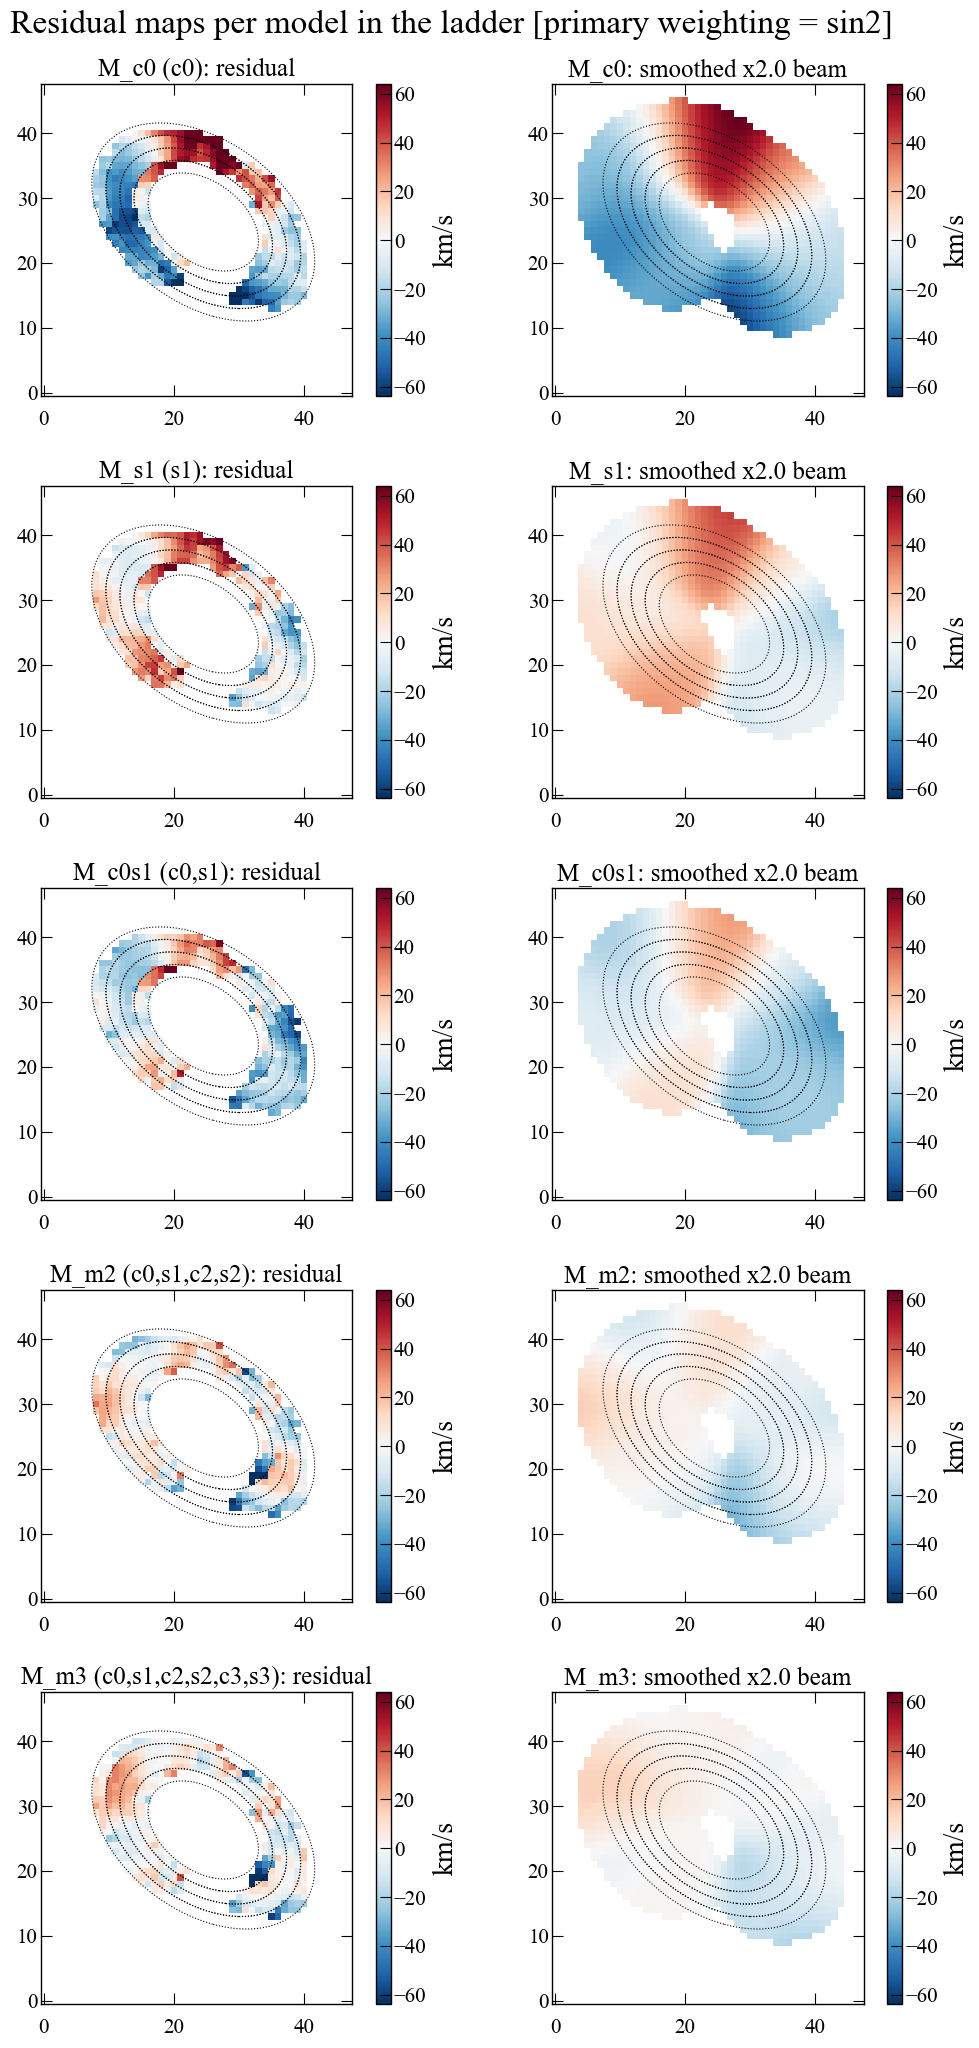

In [5]:
azp.fig_residual_ladder_maps(res)
None

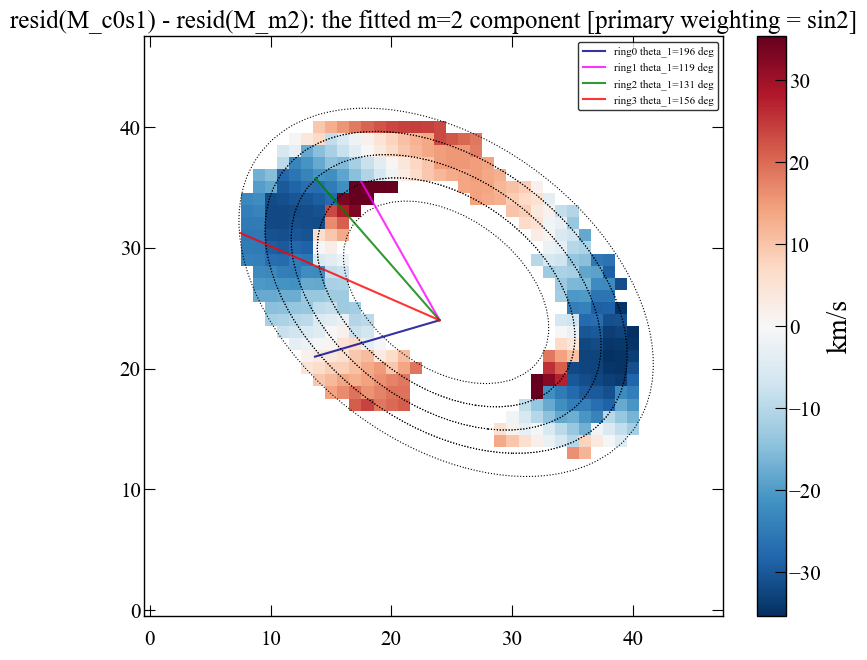

In [6]:
azp.fig_m2_component_map(res)
None

[fig_residual_histograms] pooled M_c0: rms=37.92 med=-16.67 IQR=51.44 frac>2*Lref=0.588 frac>3*Lref=0.420 (not a significance claim -- pair with the bootstrap)
[fig_residual_histograms] pooled M_s1: rms=22.87 med=3.32 IQR=26.20 frac>2*Lref=0.285 frac>3*Lref=0.124 (not a significance claim -- pair with the bootstrap)
[fig_residual_histograms] pooled M_c0s1: rms=22.95 med=-11.01 IQR=26.92 frac>2*Lref=0.295 frac>3*Lref=0.093 (not a significance claim -- pair with the bootstrap)
[fig_residual_histograms] pooled M_m2: rms=17.63 med=0.86 IQR=18.61 frac>2*Lref=0.134 frac>3*Lref=0.039 (not a significance claim -- pair with the bootstrap)
[fig_residual_histograms] pooled M_m3: rms=16.72 med=0.63 IQR=15.33 frac>2*Lref=0.122 frac>3*Lref=0.037 (not a significance claim -- pair with the bootstrap)


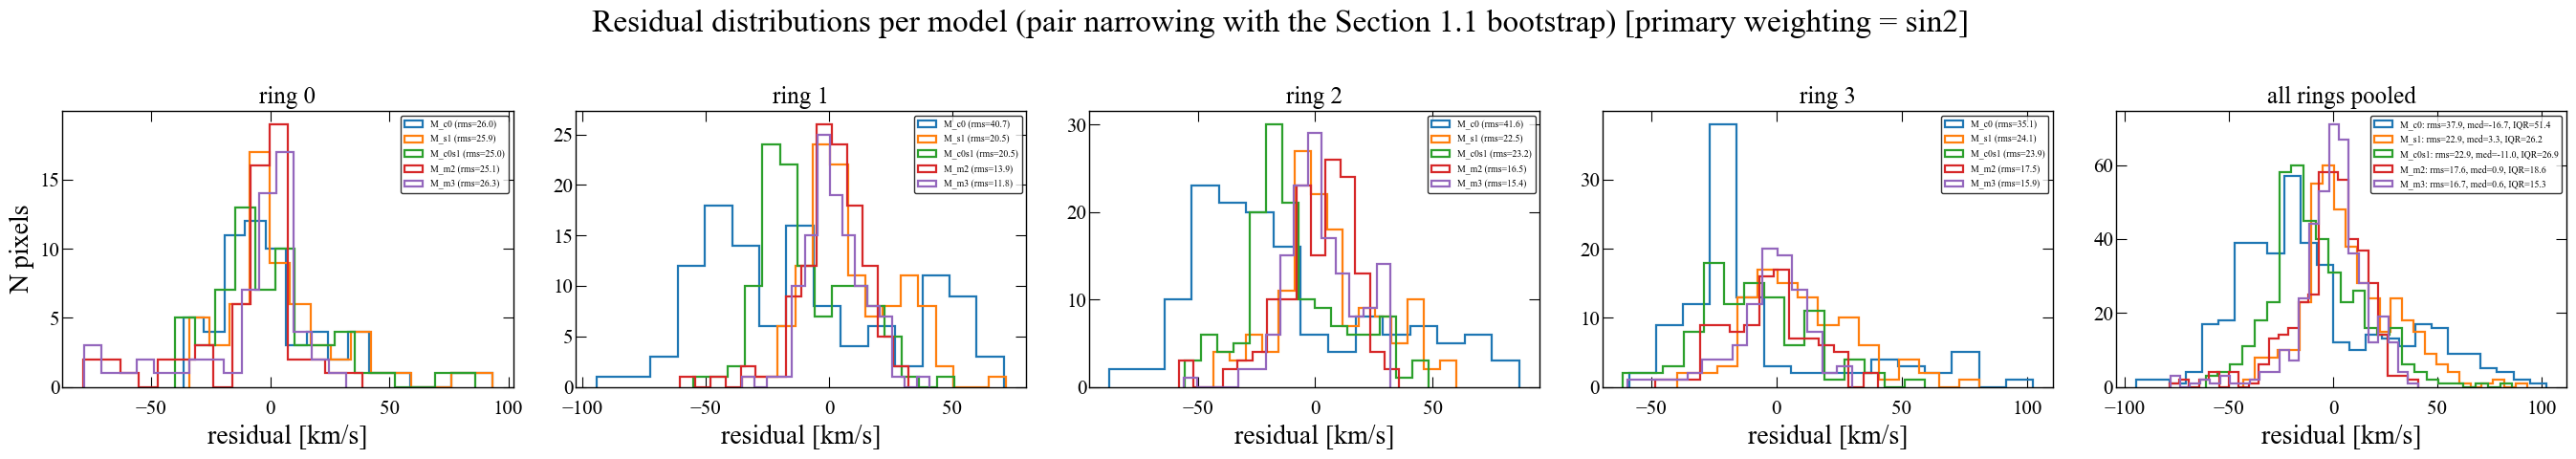

In [7]:
azp.fig_residual_histograms(res)
None

## Figures: azimuthal segment analysis (Section 2.4)

The most direct display of the hypothesis being tested. `fig_sector_analysis`
bins `M_c0s1`'s residuals into `n_sector` azimuthal sectors and overlays the
fitted `m=2` curve -- if the modulation is real, the sector means should
trace it; if they scatter randomly, `c2`/`s2` are fitting noise.
`fig_rtheta_grid` puts every ring's sectors in one `(R, theta)` image:
coherent vertical banding means a phase that doesn't change with radius,
diagonal banding means it drifts.

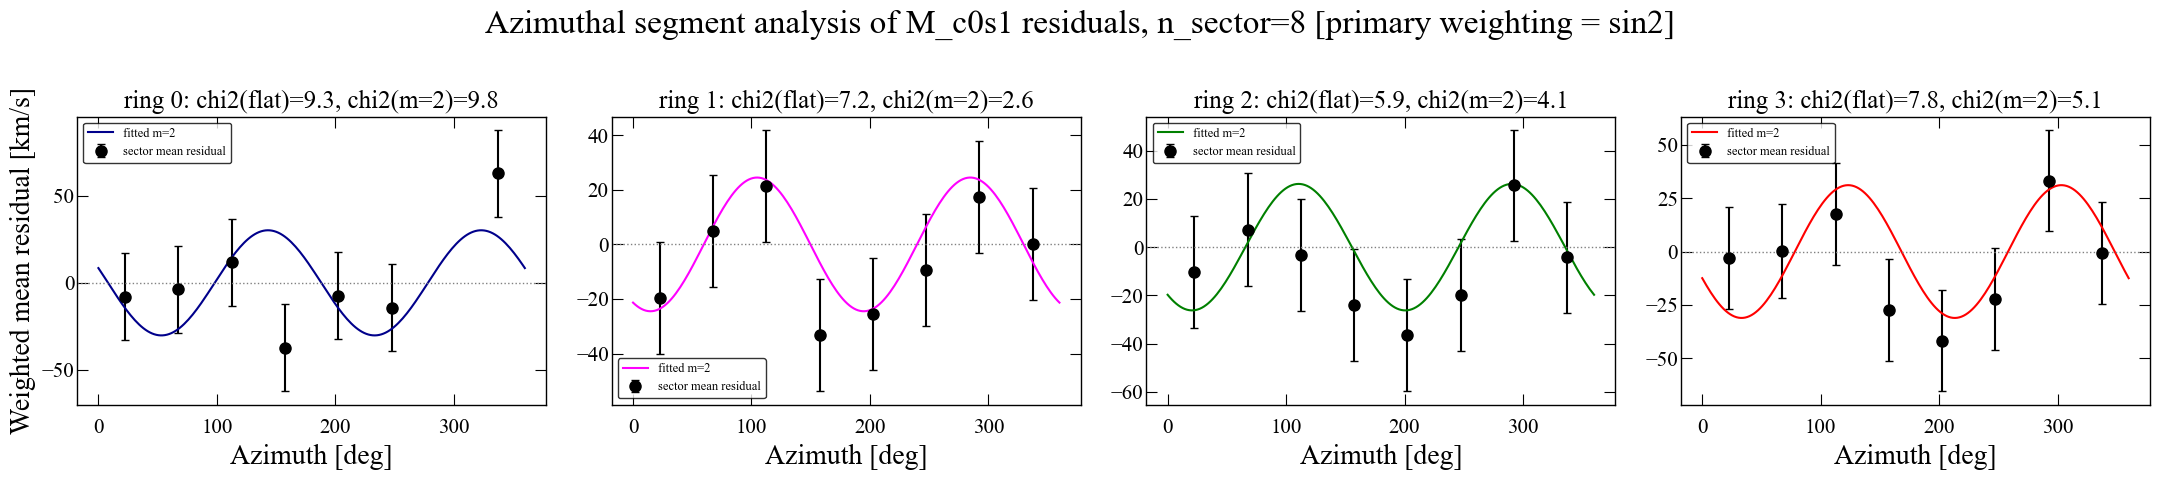

In [8]:
azp.fig_sector_analysis(res)
None

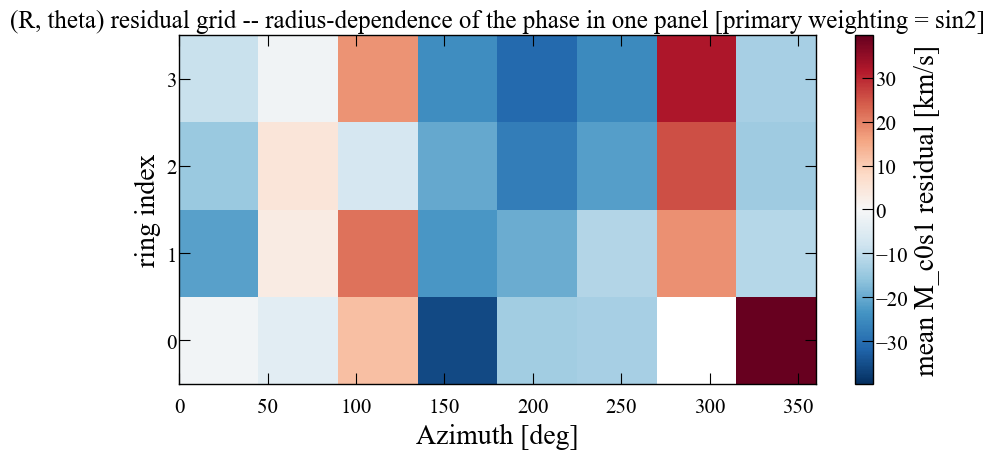

In [9]:
azp.fig_rtheta_grid(res)
None

## Figure: approaching/receding split (Section 2.5)

`s1` disagrees in sign between the two halves (already visible in
`harmonic_pipeline_TRM_paper.ipynb`'s figures); the question here is whether
`c2`, `s2` (and therefore `V_r1`, `theta_1`) agree between halves. A genuine
azimuthal modulation should appear consistently in both; a fitting artifact
need not.

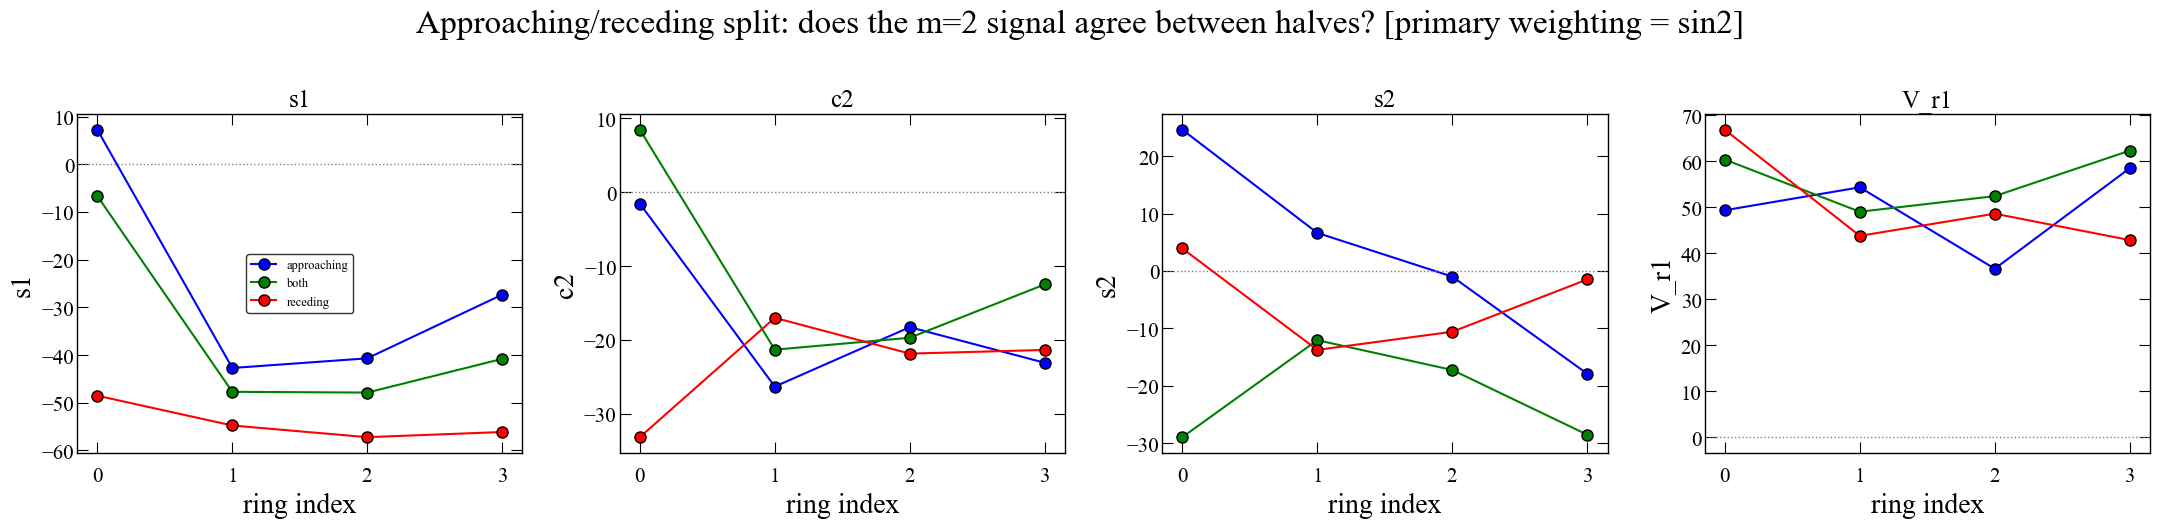

In [10]:
azp.fig_side_comparison(res)
None

## Figures: geometric alternatives (Section 3)

`c2`/`s2` are produced by an inclination error, an oval distortion, or a
warp, not only by a modulated radial flow (Schoenmakers, Franx & de Zeeuw
1997). Three scans, all holding the pixel mask fixed at the fiducial
geometry:

- **Inclination** (`fig_inclination_scan`): if `V_r1` can be driven to zero
  within a plausible inclination error, the detection is not safe.
- **Kinematic centre** (`fig_centre_scan`): the offset minimising
  `|s1_approaching - s1_receding|` -- directly testing the centring
  explanation already offered for that disagreement. Watch for "AT SCAN
  EDGE" in the title: it means the scan range was too narrow to bracket the
  true minimum for that ring.
- **Position angle** (`fig_pa_scan_vr1`): `V_r1(PA)` should be flat -- a PA
  error only produces `m=2` at second order.

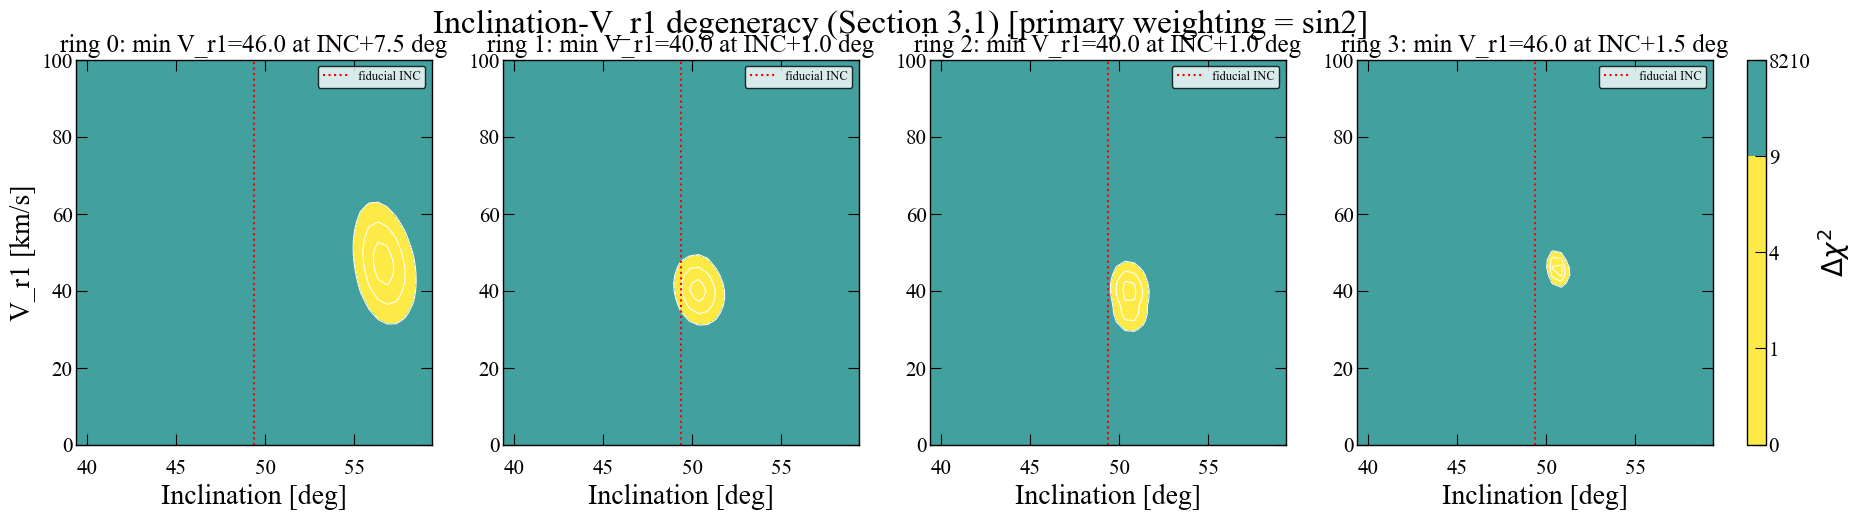

In [11]:
azp.fig_inclination_scan(res)
None

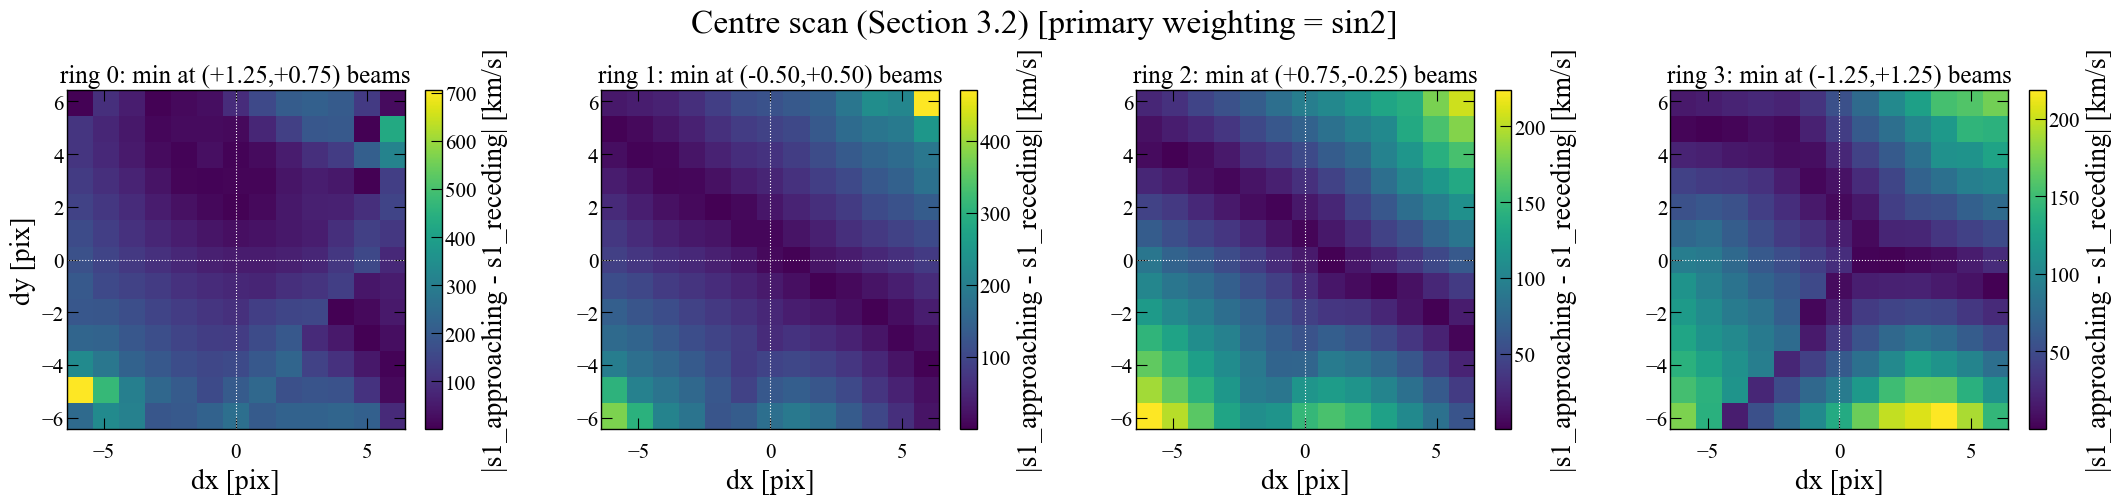

In [12]:
azp.fig_centre_scan(res)
None

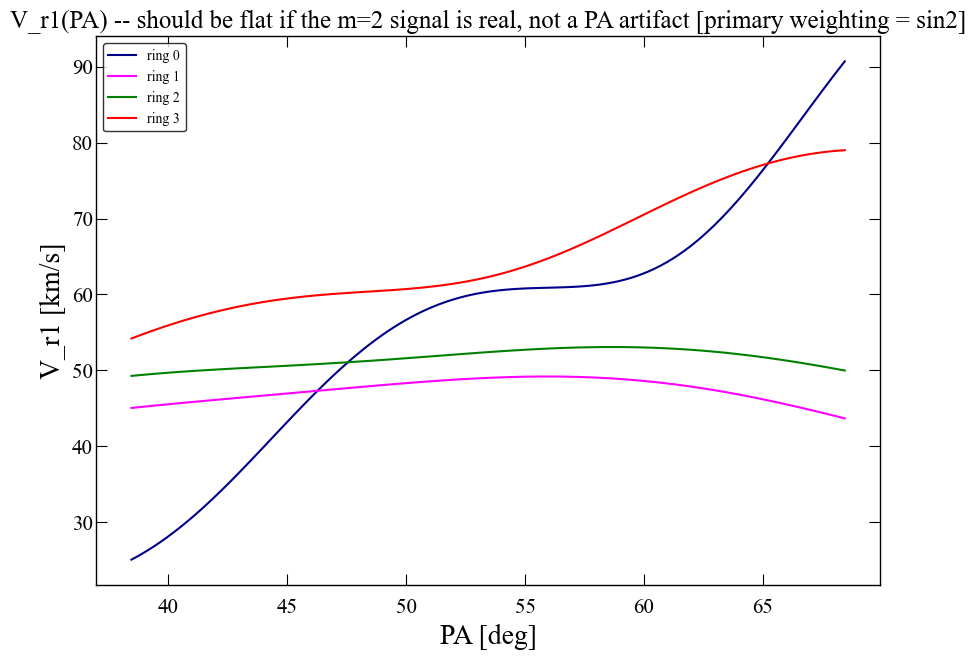

In [13]:
azp.fig_pa_scan_vr1(res)
None

## Figures: residual autocorrelation and theta_1 compass

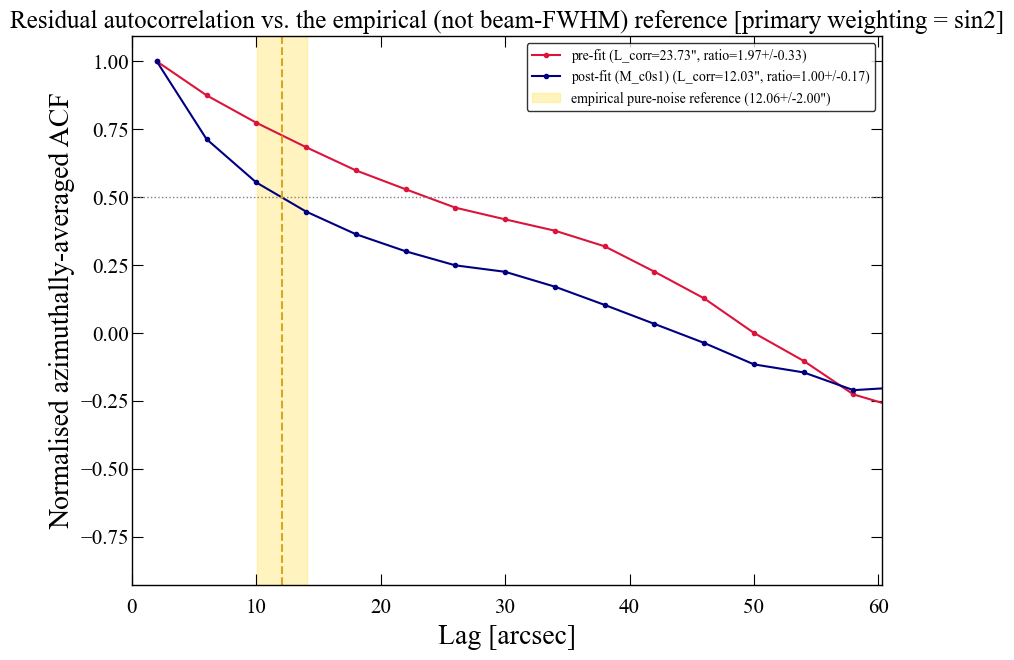

In [14]:
azp.fig_residual_autocorr(res)
None

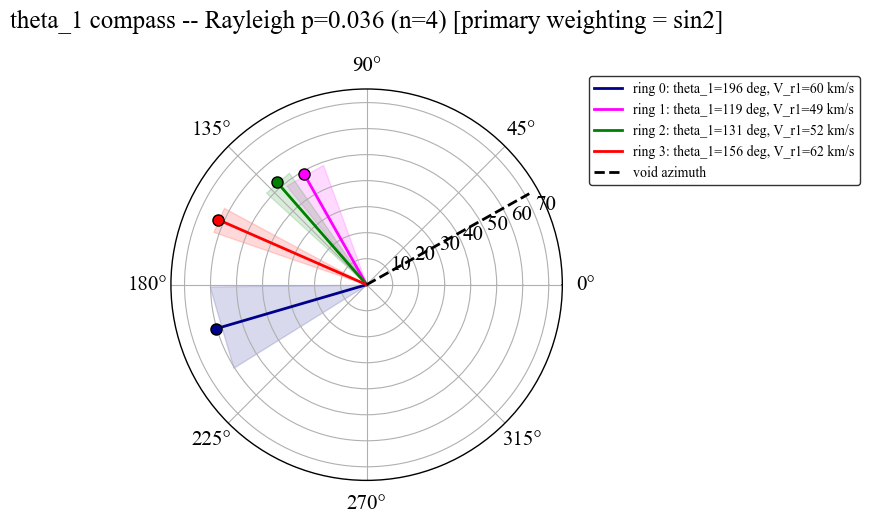

In [15]:
void_azimuth_deg = result["diagnostics"]["void_azimuth_deg"]
azp.fig_theta1_compass(res, void_azimuth_deg=void_azimuth_deg)
None

## Caveats

Each caveat below cites the number that quantifies it -- read from the run
above, not restated from a prior run.

In [16]:
diag = result["diagnostics"]
n_rings = res.n_rings
beam = diag["beam_fwhm_arcsec"]
ring_w = diag["ring_width_arcsec"]
dilution = diag["beam_dilution_ratio"]
rayleigh = diag["rayleigh_theta1"]
void_az = diag["void_azimuth_deg"]
theta1s = diag["theta1_both_per_ring_deg"]

n_eff_list = [res.row(i, model="M_m2")["n_eff"] for i in range(n_rings)]
n_overparam_m2 = sum(1 for i in range(n_rings) if bool(res.row(i, model="M_m2")["over_parameterised"]))
n_overparam_m3 = sum(1 for i in range(n_rings) if bool(res.row(i, model="M_m3")["over_parameterised"]))

print("1. Parameter count.")
print(f"   n_eff per ring = {[f'{v:.1f}' for v in n_eff_list]} against 4 params in M_m2, 6 in M_m3.")
print(f"   {n_overparam_m2}/{n_rings} rings over-parameterised at M_m2; {n_overparam_m3}/{n_rings} at M_m3.\n")

print("2. Positive-definite amplitude.")
print("   V_r1 cannot be consistent with zero by construction. Per-ring V_r1 / V_r1_debiased / "
      "V_r1_null_p50 / joint chi2_2 (formal cov, optimistic) / p_bootstrap (beam-correlated, the number to trust):")
for i in range(n_rings):
    d = diag["per_ring"][f"ring{i}"]
    vs, nb = d["vr1_summary"], d["null_bootstrap"]
    print(f"     ring{i}: V_r1={vs['V_r1']:.1f}  debiased={vs['V_r1_debiased']:.1f}  "
          f"null_p50={vs['V_r1_null_p50']:.1f}  chi2_2={vs['chi2_2']:.1f}  p_bootstrap={nb['p_bootstrap']:.3f}")
print()

print("3. Beam dilution.")
print(f"   beam FWHM = {beam:.2f}\" vs. ring width = {ring_w:.2f}\" -> ratio = {dilution:.2f}. "
      "Coherent radial motion is averaged across radii within a resolution element.\n")

print("4. Inclination degeneracy (Section 3.1).")
for i in range(n_rings):
    d = diag["per_ring"][f"ring{i}"]["inclination_scan"]
    print(f"     ring{i}: V_r1=0 reachable within scan = {d['vr1_zero_in_range']}, "
          f"min V_r1={d['vr1_min_kms']:.1f} km/s at INC offset {d['inc_offset_at_vr1_min_deg']:+.1f} deg")
print()

print("5. Warp.")
print("   A radially varying position angle reproduces ring-dependent behaviour as naturally as a "
      "modulated flow and cannot be separated from it with a line-of-sight velocity field alone "
      "(Sylos Labini et al. 2025).\n")

print("6. Phase coherence, and what it is worth.")
print(f"   theta_1 = {[f'{v:.1f}' for v in theta1s]} deg, scatter = {np.std(theta1s):.1f} deg.")
print(f"   Rayleigh test: Rbar={rayleigh['Rbar']:.3f}, z={rayleigh['z']:.3f}, p={rayleigh['p']:.4f} (n={rayleigh['n']}).")
print(f"   Beam ({beam:.1f}\") exceeds the ring width ({ring_w:.1f}\"), so the {n_rings} rings are not "
      "independent -- read p as suggestive, not a calibrated small-n result.\n")

print("7. The morphological cross-check failed.")
if void_az is not None:
    mean_theta1 = np.degrees(np.arctan2(np.mean(np.sin(np.radians(theta1s))), np.mean(np.cos(np.radians(theta1s))))) % 360
    print(f"   Void azimuth (disk frame) = {void_az:.1f} deg vs. theta_1 ~ {mean_theta1:.1f} deg: "
          f"neither aligned nor anti-aligned (difference = {min(abs(void_az-mean_theta1), 360-abs(void_az-mean_theta1)):.1f} deg). "
          "The modulation phase does not point at the void, so the off-centre-impact interpretation "
          "has no independent morphological support.\n")
else:
    print("   Void azimuth cross-check unavailable for this TRM model.\n")

print("8. Gas cannot multi-stream.")
print("   Wallin & Struck-Marcell's Fig. 6 shows infalling and outflowing particles coexisting at one "
      "position, which HI cannot do. Azimuthal modulation (different theta, same R) remains available "
      "as an explanation; multi-streaming at a point does not.\n")

print("9. Coincidence with the alternative TRM.")
print(f"   V_r1 ~ {min(res.rows(side='both', model='M_m2')['c2']**2 + res.rows(side='both', model='M_m2')['s2']**2)**0.5*2:.0f}"
      f"-{max((res.rows(side='both', model='M_m2')['c2']**2 + res.rows(side='both', model='M_m2')['s2']**2)**0.5*2):.0f} km/s "
      "is close to the s1 ~ 47 km/s obtained at PA = 53.445 (the other TRM model). A PA error generates m=2 "
      "only at second order (~5 km/s at dphi=11 deg), so this is not a direct artifact, but the numerical "
      "closeness should be stated.")

1. Parameter count.
   n_eff per ring = ['2.9', '5.5', '6.7', '4.7'] against 4 params in M_m2, 6 in M_m3.
   1/4 rings over-parameterised at M_m2; 3/4 at M_m3.

2. Positive-definite amplitude.
   V_r1 cannot be consistent with zero by construction. Per-ring V_r1 / V_r1_debiased / V_r1_null_p50 / joint chi2_2 (formal cov, optimistic) / p_bootstrap (beam-correlated, the number to trust):
     ring0: V_r1=60.4  debiased=58.4  null_p50=60.6  chi2_2=23.2  p_bootstrap=0.375
     ring1: V_r1=49.0  debiased=48.3  null_p50=48.0  chi2_2=30.4  p_bootstrap=0.396
     ring2: V_r1=52.4  debiased=52.0  null_p50=51.1  chi2_2=54.0  p_bootstrap=0.376
     ring3: V_r1=62.3  debiased=62.1  null_p50=62.3  chi2_2=116.5  p_bootstrap=0.378

3. Beam dilution.
   beam FWHM = 17.09" vs. ring width = 9.70" -> ratio = 1.76. Coherent radial motion is averaged across radii within a resolution element.

4. Inclination degeneracy (Section 3.1).
     ring0: V_r1=0 reachable within scan = False, min V_r1=46.0 km/s at IN

## Verdict

In [17]:
v = diag["verdict"]
print(f"VERDICT: {v['verdict']}")
print(f"  p_bootstrap < 0.05: {v['n_rings_p_bootstrap_lt_0.05']}/{n_rings} rings -- {v['p_bootstrap_per_ring']}")
print(f"  joint (c2,s2) chi2_2 > 5.99 (95%, 2 dof, formal cov): {v['n_rings_chi2_2_gt_5.99']}/{n_rings} rings -- "
      f"{[f'{c:.1f}' for c in v['chi2_2_per_ring']]}")
print(f"  inclination-safe (V_r1=0 unreachable within scan): {v['n_rings_inclination_safe']}/{n_rings} rings")
print()
print("Read alongside caveats 1-9 above -- in particular, chi2_2 uses the formal (pixel-independence-"
      "assuming) covariance and is optimistic; p_bootstrap is the number that accounts for beam "
      "correlation and is also, per azimuthal_modulation.py's own calibration note, itself somewhat "
      "conservative -- so a p_bootstrap in the 0.3-0.5 range is not strong evidence for the null either.")

VERDICT: MARGINAL
  p_bootstrap < 0.05: 0/4 rings -- [0.375, 0.396, 0.3755, 0.3775]
  joint (c2,s2) chi2_2 > 5.99 (95%, 2 dof, formal cov): 4/4 rings -- ['23.2', '30.4', '54.0', '116.5']
  inclination-safe (V_r1=0 unreachable within scan): 4/4 rings

Read alongside caveats 1-9 above -- in particular, chi2_2 uses the formal (pixel-independence-assuming) covariance and is optimistic; p_bootstrap is the number that accounts for beam correlation and is also, per azimuthal_modulation.py's own calibration note, itself somewhat conservative -- so a p_bootstrap in the 0.3-0.5 range is not strong evidence for the null either.
